# FinSight Builder

FinSight Builder is an AI-assisted software engineering notebook that generates a complete lightweight web application from a finance club problem statement. The generated product, FinSight Club Dashboard, supports weekly stock discussion sessions by providing sample stock cards, educational risk briefings, watchlist input, risk summaries, and feedback collection. The project focuses on structured learning rather than financial decision-making, so prediction, trading advice, and investment recommendations are deliberately out of scope.


## Setup & Environment

Load the baseline helpers, prepare output folders, and keep API keys out of notebook output.

In [1]:
from pathlib import Path
import json
import contextlib
import io
import os
import re
import sys

from IPython.display import display, Markdown, Image as IPyImage
from PIL import Image, ImageDraw, ImageFont

TASK1_DIR = Path.cwd().resolve() if Path.cwd().name == "Task1" else Path.cwd().resolve() / "Task1"
REPO_ROOT = TASK1_DIR.parent
if str(TASK1_DIR) not in sys.path:
    sys.path.insert(0, str(TASK1_DIR))

ARTIFACTS = TASK1_DIR / "artifacts"
DIAGRAM_DIR = ARTIFACTS / "diagrams"
APP_DIR = ARTIFACTS / "app"
FLASK_DIR = APP_DIR / "flask"
STATIC_DIR = FLASK_DIR / "static"
TEST_DIR = APP_DIR / "tests"
DOCKER_DIR = APP_DIR / "docker"
CI_DIR = APP_DIR / ".github" / "workflows"
TASK2_WORKFLOW_DIR = REPO_ROOT / "Task2" / "github_workflow_copy"
ROOT_CI_DIR = REPO_ROOT / ".github" / "workflows"

for path in [ARTIFACTS, DIAGRAM_DIR, FLASK_DIR, STATIC_DIR, TEST_DIR, DOCKER_DIR, CI_DIR, TASK2_WORKFLOW_DIR, ROOT_CI_DIR]:
    path.mkdir(parents=True, exist_ok=True)

try:
    from utils import load_environment, setup_llm_client, get_completion, clean_llm_output, render_plantuml_diagram, get_image_generation_completion
except Exception as exc:
    print(f"Baseline utils unavailable; controlled fallbacks remain active: {type(exc).__name__}")
    def load_environment(): return None
    def setup_llm_client(model_name="openai/gpt-5.2"): return None, model_name, None
    def get_completion(prompt, client, model_name, api_provider, temperature=0.3): return ""
    def clean_llm_output(output_str, language="markdown"): return str(output_str or "").strip()
    def render_plantuml_diagram(puml_code, output_path="artifacts/diagram.png"): raise RuntimeError("PlantUML helper unavailable")
    def get_image_generation_completion(prompt, client, model_name, api_provider): return None

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    load_environment()
client, model_name, api_provider = None, None, None
try:
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        client, model_name, api_provider = setup_llm_client(os.getenv("FINSIGHT_TEXT_MODEL", "openai/gpt-5.2"))
except Exception as exc:
    print(f"LLM client setup skipped: {type(exc).__name__}")

image_client, image_model_name, image_api_provider = None, None, None
try:
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        image_client, image_model_name, image_api_provider = setup_llm_client(os.getenv("FINSIGHT_IMAGE_MODEL", "qwen/qwen-image-2512"))
except Exception:
    pass

def save_text(path, content):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(str(content).strip() + "\n", encoding="utf-8")
    print(f"Saved: {path.relative_to(REPO_ROOT)}")

def preview_markdown(content, max_chars=2400):
    if isinstance(content, Path) and content.exists():
        text = content.read_text(encoding="utf-8").strip()
    else:
        text = str(content).strip()
    display(Markdown(text[:max_chars] + ("\n\n..." if len(text) > max_chars else "")))

def fill_prompt(template, **kwargs):
    text = str(template)
    for key, value in kwargs.items():
        text = text.replace("{" + key + "}", str(value))
    return text

def clean_generated(raw, language="markdown"):
    text = clean_llm_output(raw, language=language) if raw else ""
    return text.strip()

print({"llm_client_available": bool(client), "model": model_name, "api_provider": api_provider, "image_client_available": bool(image_client), "keys_printed": False})


To enable full functionality run: pip install python-dotenv ipython plantuml
{'llm_client_available': False, 'model': None, 'api_provider': None, 'image_client_available': False, 'keys_printed': False}


# Phase 1: Inception

The inception phase turns the finance club problem into product documentation for FinSight Club Dashboard.

#### 1) Business Intent

The business problem stays fixed and drives the generated artefacts.

In [2]:
generator_name = "FinSight Builder"
product_name = "FinSight Club Dashboard"
business_problem = 'A university finance club needs a lightweight educational web application to support weekly stock discussion sessions. Students need to organise a small stock watchlist, read simple educational risk briefings, understand basic risk categories, and submit feedback after each session. The club does not need stock prediction, trading advice, or investment recommendations. It needs a simple, deployable Flask web application that can be generated through an AI-driven software development workflow.'
display(Markdown(f'**Generator layer:** {generator_name}\n\n**Generated application:** {product_name}\n\n**Business problem**\n\n' + business_problem))


**Generator layer:** FinSight Builder

**Generated application:** FinSight Club Dashboard

**Business problem**

A university finance club needs a lightweight educational web application to support weekly stock discussion sessions. Students need to organise a small stock watchlist, read simple educational risk briefings, understand basic risk categories, and submit feedback after each session. The club does not need stock prediction, trading advice, or investment recommendations. It needs a simple, deployable Flask web application that can be generated through an AI-driven software development workflow.

#### 2) AI generated - Problem Statement

Generate a concise product problem statement and save it for later stages.

In [3]:
problem_statement_prompt = """You are an AI software engineering analyst. Given the business problem below, generate one concise problem statement for the generated software product.

Business problem:
{business_problem}

Rules:
- Write from the perspective of the generated Flask product, FinSight Club Dashboard.
- Do not describe the generator notebook as the product.
- Keep the product focused on university finance club users, educational stock watchlist, risk briefings, risk categories, and feedback.
- Include the product name FinSight Club Dashboard.
- Do not include stock prediction, trading advice, buy/sell recommendation, portfolio optimisation, investment recommendation, or real-money decision support.
- Output Markdown with heading '# Problem Statement'."""
print("Generating: problem_statement")
problem_statement_fallback = "# Problem Statement\n\nA university finance club runs regular stock discussion sessions, but students often prepare with scattered notes, inconsistent watchlists, and uneven understanding of basic risk factors. This makes sessions harder to organise and can shift discussion toward unsupported opinions rather than structured learning.\n\nThe club needs a lightweight educational tool for a small shared watchlist, simple risk briefings, basic risk categories, and post-session feedback. The product boundary is explicit: it must not provide stock prediction, trading advice, buy/sell recommendations, portfolio optimisation, investment recommendations, or real-money decision support.\n"
prompt = fill_prompt(problem_statement_prompt, business_problem=business_problem)
if client:
    generated = get_completion(prompt, client, model_name, api_provider, temperature=0.4)
    problem_statement = clean_generated(generated) or problem_statement_fallback
else:
    problem_statement = problem_statement_fallback
problem_statement_checks = ("scattered notes", "inconsistent watchlists", "unsupported opinions")
if not all(check in problem_statement.lower() for check in problem_statement_checks):
    problem_statement = problem_statement_fallback
save_text(ARTIFACTS / "problem_statement.md", problem_statement)
preview_markdown(ARTIFACTS / "problem_statement.md")


Generating: problem_statement
Saved: Task1\artifacts\problem_statement.md


# Problem Statement

A university finance club runs regular stock discussion sessions, but students often prepare with scattered notes, inconsistent watchlists, and uneven understanding of basic risk factors. This makes sessions harder to organise and can shift discussion toward unsupported opinions rather than structured learning.

The club needs a lightweight educational tool for a small shared watchlist, simple risk briefings, basic risk categories, and post-session feedback. The product boundary is explicit: it must not provide stock prediction, trading advice, buy/sell recommendations, portfolio optimisation, investment recommendations, or real-money decision support.

#### 3) AI generated - Personas

Generate practical personas in the concise role format used in the baseline notebook.

In [4]:
personas_prompt = """Generate personas for FinSight Club Dashboard using this format exactly:

Personas: <one-sentence intro>

1. **Beginner Student Investor**
   - **Responsibilities:** ...
   - **Needs:** ...

2. **Finance Club Member**
   - **Responsibilities:** ...
   - **Needs:** ...

3. **Club Organiser**
   - **Responsibilities:** ...
   - **Needs:** ...

4. **Finance Workshop Facilitator**
   - **Responsibilities:** ...
   - **Needs:** ...

Problem statement:
{problem_statement}

Use product users only. Output Markdown with heading '# Personas'."""
print("Generating: personas")
personas_fallback = '''# Personas

Personas: FinSight Club Dashboard supports students and facilitators involved in weekly finance club learning sessions.

1. **Beginner Student Investor**
   - **Responsibilities:** Prepare for discussion by reviewing sample stock cards and risk categories.
   - **Needs:** Simple language, visible risk labels, and reassurance that the product is educational.

2. **Finance Club Member**
   - **Responsibilities:** Compare a small set of sample stocks before and during club sessions.
   - **Needs:** A focused watchlist, short briefings, and clear low, medium, and high risk categories.

3. **Club Organiser**
   - **Responsibilities:** Guide weekly sessions and collect feedback from participants.
   - **Needs:** A lightweight dashboard, reliable feedback form, and consistent session materials.

4. **Finance Workshop Facilitator**
   - **Responsibilities:** Help students discuss market examples using shared educational vocabulary.
   - **Needs:** Clear risk summaries, non-advisory wording, and a website that can support classroom demonstrations.
'''
prompt = fill_prompt(personas_prompt, problem_statement=problem_statement)
if client:
    generated = get_completion(prompt, client, model_name, api_provider, temperature=0.4)
    personas = clean_generated(generated) or personas_fallback
else:
    personas = personas_fallback
persona_banned_terms = ("approve", "export", "admin controls", "change log", "week-to-week", "catalysts", "aggregated feedback")
if any(term in personas.lower() for term in persona_banned_terms):
    personas = personas_fallback
save_text(ARTIFACTS / "personas.md", personas)
preview_markdown(ARTIFACTS / "personas.md")

Generating: personas
Saved: Task1\artifacts\personas.md


# Personas

Personas: FinSight Club Dashboard supports students and facilitators involved in weekly finance club learning sessions.

1. **Beginner Student Investor**
   - **Responsibilities:** Prepare for discussion by reviewing sample stock cards and risk categories.
   - **Needs:** Simple language, visible risk labels, and reassurance that the product is educational.

2. **Finance Club Member**
   - **Responsibilities:** Compare a small set of sample stocks before and during club sessions.
   - **Needs:** A focused watchlist, short briefings, and clear low, medium, and high risk categories.

3. **Club Organiser**
   - **Responsibilities:** Guide weekly sessions and collect feedback from participants.
   - **Needs:** A lightweight dashboard, reliable feedback form, and consistent session materials.

4. **Finance Workshop Facilitator**
   - **Responsibilities:** Help students discuss market examples using shared educational vocabulary.
   - **Needs:** Clear risk summaries, non-advisory wording, and a website that can support classroom demonstrations.

#### 4) AI generated - PRD / Requirements

Generate a compact PRD that describes the product, users, flows, and constraints.

In [5]:
prd_prompt = """Generate a compact Product Requirements Document for FinSight Club Dashboard.

Problem statement:
{problem_statement}

Personas:
{personas}

Use only these headings:
## Overview
## Goals
## Non-Goals
## User Personas
## Key Features
## User Flows
## Functional Requirements
## Non-Functional Requirements
## Constraints/Assumptions
## Success Metrics
## Open Questions

Keep each heading concise with 2-4 bullets. Focus on the Flask product and its finance club users. Output Markdown with heading '# Product Requirements Document'."""
print("Generating: prd")
prd_fallback = '''# Product Requirements Document

## Overview
- FinSight Club Dashboard is a Flask API and website for weekly university finance club discussions.
- The product presents fixed sample stocks, educational risk briefings, risk category summaries, and feedback collection.

## Goals
- Help students prepare for discussion with a small educational stock watchlist.
- Explain low, medium, and high risk categories in plain English.
- Let organisers collect feedback after each session.

## Non-Goals
- The product is not a live market-data platform.
- The product does not provide financial advice or real-money decision support.
- The product does not require accounts or a persistent database.

## User Personas
- Beginner Student Investor: needs approachable explanations and visible risk labels.
- Finance Club Member: needs a focused watchlist and short risk context.
- Club Organiser: needs feedback collection and predictable session materials.
- Finance Workshop Facilitator: needs a teaching aid with clear educational boundaries.

## Key Features
- Stock briefing cards with ticker, company name, sector, mock price, risk level, and briefing.
- Watchlist form for supported tickers.
- Risk summary grouped by low, medium, and high categories.
- Feedback form with rating validation.

## User Flows
- A student opens the dashboard, reviews stock cards, and reads the risk summary.
- A member adds a supported ticker to the watchlist.
- An organiser collects feedback after the session.

## Functional Requirements
- Serve the dashboard at `/` and JSON health data at `/health`.
- Return stock list and single-ticker briefing data through API endpoints.
- Validate watchlist and feedback submissions.
- Display the generated market education banner and required disclaimer.

## Non-Functional Requirements
- Keep the interface responsive and readable for beginner users.
- Use fixed sample data for reproducible demonstrations.
- Return clear JSON errors for invalid input.

## Constraints/Assumptions
- Stock prices are mock values used only for education.
- Watchlist and feedback can be stored in memory for the lightweight version.
- The application should run locally with simple Python dependencies.

## Success Metrics
- Users can load the dashboard and see the generated image.
- Users can add a supported ticker and submit valid feedback.
- Invalid inputs return understandable errors.

## Open Questions
- Which sample stocks should the finance club prefer for future sessions?
- Should organisers export feedback after the lightweight version is reviewed?
'''
prompt = fill_prompt(prd_prompt, problem_statement=problem_statement, personas=personas)
if client:
    generated = get_completion(prompt, client, model_name, api_provider, temperature=0.4)
    prd = clean_generated(generated) or prd_fallback
else:
    prd = prd_fallback
prd_banned_terms = ("approval workflow", "csv", "change log", "role access", "session model", "admin/insights", "authentication", "sqlite", "postgres")
if any(term in prd.lower() for term in prd_banned_terms):
    prd = prd_fallback
prd = prd.replace("- Should organisers export feedback after the lightweight version is reviewed?\n", "")
save_text(ARTIFACTS / "prd.md", prd)
preview_markdown(ARTIFACTS / "prd.md")

Generating: prd
Saved: Task1\artifacts\prd.md


# Product Requirements Document

## Overview
- FinSight Club Dashboard is a Flask API and website for weekly university finance club discussions.
- The product presents fixed sample stocks, educational risk briefings, risk category summaries, and feedback collection.

## Goals
- Help students prepare for discussion with a small educational stock watchlist.
- Explain low, medium, and high risk categories in plain English.
- Let organisers collect feedback after each session.

## Non-Goals
- The product is not a live market-data platform.
- The product does not provide financial advice or real-money decision support.
- The product does not require accounts or a persistent database.

## User Personas
- Beginner Student Investor: needs approachable explanations and visible risk labels.
- Finance Club Member: needs a focused watchlist and short risk context.
- Club Organiser: needs feedback collection and predictable session materials.
- Finance Workshop Facilitator: needs a teaching aid with clear educational boundaries.

## Key Features
- Stock briefing cards with ticker, company name, sector, mock price, risk level, and briefing.
- Watchlist form for supported tickers.
- Risk summary grouped by low, medium, and high categories.
- Feedback form with rating validation.

## User Flows
- A student opens the dashboard, reviews stock cards, and reads the risk summary.
- A member adds a supported ticker to the watchlist.
- An organiser collects feedback after the session.

## Functional Requirements
- Serve the dashboard at `/` and JSON health data at `/health`.
- Return stock list and single-ticker briefing data through API endpoints.
- Validate watchlist and feedback submissions.
- Display the generated market education banner and required disclaimer.

## Non-Functional Requirements
- Keep the interface responsive and readable for beginner users.
- Use fixed sample data for reproducible demonstrations.
- Return clear JSON errors for invalid input.

## Constraints/Assumptions
- Stock prices are mock values used only for education.
- Watchlist and feedback can be stored in memory for the lightweight version.
- The application should run locally with simple Python dependencies.

## Success Metrics
- Users can load the dashboard and see the generated image.
- Users can add a supported ticker and submit valid feedback.
- Invalid inputs return understandable errors.

## 

...

#### 5) AI generated - User Stories

Generate short JSON user stories that can drive API and UI construction.

In [6]:
user_stories_prompt = """Return ONLY valid JSON using exactly this schema:
{
  "user_stories": [
    {
      "id": 1,
      "role": "Beginner Student Investor",
      "goal": "...",
      "benefit": "...",
      "acceptance_criteria": ["...", "..."]
    }
  ]
}

PRD:
{prd}

Personas:
{personas}

Rules: provide 5 concise stories; use integer ids; use only id, role, goal, benefit, and acceptance_criteria; keep acceptance criteria short and testable."""
print("Generating: user_stories")
user_stories_fallback = '''{
  "user_stories": [
    {"id": 1, "role": "Beginner Student Investor", "goal": "View sample stock cards with risk labels", "benefit": "I can prepare for a finance club discussion with clear context", "acceptance_criteria": ["Stock cards show ticker, name, sector, mock price, risk level, and briefing", "The required educational disclaimer is visible"]},
    {"id": 2, "role": "Finance Club Member", "goal": "Read a simple risk briefing for each sample stock", "benefit": "I can discuss risk categories using shared language", "acceptance_criteria": ["Each stock has a plain-language briefing", "Risk levels are low, medium, or high"]},
    {"id": 3, "role": "Finance Club Member", "goal": "Add a supported ticker to the watchlist", "benefit": "I can focus the weekly discussion on selected examples", "acceptance_criteria": ["Supported tickers can be added", "Missing or unsupported tickers return an error"]},
    {"id": 4, "role": "Club Organiser", "goal": "Collect feedback after a session", "benefit": "I can improve future discussion topics", "acceptance_criteria": ["Feedback requires name, message, and rating", "Ratings outside 1 to 5 are rejected"]},
    {"id": 5, "role": "Finance Workshop Facilitator", "goal": "Show risk category summaries", "benefit": "Students can compare examples using consistent categories", "acceptance_criteria": ["The dashboard shows low, medium, and high counts", "The API returns the same risk summary"]}
  ]
}'''
prompt = fill_prompt(user_stories_prompt, prd=prd, personas=personas)
if client:
    generated = get_completion(prompt, client, model_name, api_provider, temperature=0.3)
    user_stories_text = clean_generated(generated, language='json') or user_stories_fallback
else:
    user_stories_text = user_stories_fallback
try:
    user_stories_json = json.loads(user_stories_text)
    allowed = {"id", "role", "goal", "benefit", "acceptance_criteria"}
    for item in user_stories_json.get("user_stories", []):
        for key in list(item.keys()):
            if key not in allowed:
                item.pop(key)
        if isinstance(item.get("id"), str) and item["id"].isdigit():
            item["id"] = int(item["id"])
except Exception:
    user_stories_json = json.loads(user_stories_fallback)
story_text = json.dumps(user_stories_json).lower()
story_banned_terms = ("approve", "export", "csv", "change log", "current session", "role management", "admin")
if len(user_stories_json.get("user_stories", [])) != 5 or any(term in story_text for term in story_banned_terms):
    user_stories_json = json.loads(user_stories_fallback)
save_text(ARTIFACTS / "user_stories.json", json.dumps(user_stories_json, indent=2))
print((ARTIFACTS / "user_stories.json").read_text(encoding='utf-8')[:1200])

Generating: user_stories
Saved: Task1\artifacts\user_stories.json
{
  "user_stories": [
    {
      "id": 1,
      "role": "Beginner Student Investor",
      "goal": "View sample stock cards with risk labels",
      "benefit": "I can prepare for a finance club discussion with clear context",
      "acceptance_criteria": [
        "Stock cards show ticker, name, sector, mock price, risk level, and briefing",
        "The required educational disclaimer is visible"
      ]
    },
    {
      "id": 2,
      "role": "Finance Club Member",
      "goal": "Read a simple risk briefing for each sample stock",
      "benefit": "I can discuss risk categories using shared language",
      "acceptance_criteria": [
        "Each stock has a plain-language briefing",
        "Risk levels are low, medium, or high"
      ]
    },
    {
      "id": 3,
      "role": "Finance Club Member",
      "goal": "Add a supported ticker to the watchlist",
      "benefit": "I can focus the weekly discussion on selec

#### 6) AI generated - API Specification

Generate the API contract from the PRD and user stories before code construction.

In [7]:
api_spec_prompt = """You are a backend API designer. Generate a concise Flask API specification for the generated product FinSight Club Dashboard.

PRD:
{prd}

User stories JSON:
{user_stories_text}

Required endpoints:
GET /
GET /stock/<ticker>
GET /health
GET /api/stocks
GET /api/stocks/<ticker>
POST /api/watchlist
GET /api/watchlist
GET /api/risk-summary
POST /api/feedback
GET /api/feedback

Rules:
- Write from the perspective of the generated Flask product, FinSight Club Dashboard.
- Do not describe the generator notebook as the product.
- Keep the product focused on university finance club users, educational stock watchlist, risk briefings, risk categories, and feedback.
- Use fixed sample stock data.
- Include validation behavior for unknown tickers and invalid feedback.
- Include the visible educational disclaimer.
- Put GET / and GET /stock/<ticker> under a small Website Routes section, not among the REST API endpoints.
- Do not include stock prediction, trading advice, buy/sell recommendation, portfolio optimisation, investment recommendation, or real-money decision support.
- Output Markdown with heading '# API Specification'."""
print("Generating: api_spec")
api_spec_fallback = '# API Specification\n\nApplication: FinSight Club Dashboard\nBase URL: http://127.0.0.1:5005\nDisclaimer: For educational demonstration only. Not financial advice.\n\n## Website Routes\n- `GET /`: serves the English website interface with the generated market education banner, sample stock cards, watchlist form, feedback form, and visible disclaimer.\n- `GET /stock/<ticker>`: serves the stock detail page, which loads the supported ticker briefing from `GET /api/stocks/<ticker>`.\n\n## GET /health\nReturns service health information.\n\nExample response:\n```json\n{"status": "ok", "service": "FinSight Club Dashboard", "disclaimer": "For educational demonstration only. Not financial advice."}\n```\n\n## GET /api/stocks\nReturns the fixed educational sample stock list.\n\nResponse fields include ticker, name, sector, mock_price, risk_level, and briefing.\n\n## GET /api/stocks/<ticker>\nReturns one stock briefing for a supported ticker. Unknown tickers return 404 with `stock_not_found`.\n\n## POST /api/watchlist\nAdds a supported ticker to the in-memory watchlist.\n\nRequest body:\n```json\n{"ticker": "AAPL"}\n```\nValidation:\n- Missing ticker returns 400.\n- Unsupported ticker returns 404.\n\n## GET /api/watchlist\nReturns the current in-memory watchlist as both ticker symbols and stock objects.\n\n## GET /api/risk-summary\nReturns counts for low, medium, and high risk categories.\n\n## POST /api/feedback\nAccepts post-session feedback.\n\nRequest body:\n```json\n{"name": "Student", "message": "Useful discussion", "rating": 5}\n```\nValidation:\n- name, message, and rating are required.\n- rating must be an integer from 1 to 5.\n\n## GET /api/feedback\nReturns submitted feedback items and a count.\n\n## Boundary\nThe API returns educational sample data only. It does not provide prediction, trading advice, buy/sell recommendations, portfolio optimisation, investment recommendations, or real-money decision support.\n'
prompt = fill_prompt(api_spec_prompt, prd=prd, user_stories_text=user_stories_text)
if client:
    generated = get_completion(prompt, client, model_name, api_provider, temperature=0.3)
    api_spec = clean_generated(generated) or api_spec_fallback
else:
    api_spec = api_spec_fallback
required_api_routes = ("## Website Routes", "`GET /`", "`GET /stock/<ticker>`", "## GET /health", "## GET /api/stocks", "## GET /api/stocks/<ticker>", "## POST /api/watchlist", "## GET /api/watchlist", "## GET /api/risk-summary", "## POST /api/feedback", "## GET /api/feedback")
if not all(route in api_spec for route in required_api_routes):
    api_spec = api_spec_fallback
save_text(ARTIFACTS / "api_spec.md", api_spec)
preview_markdown(ARTIFACTS / "api_spec.md", max_chars=900)
endpoint_lines = [line for line in api_spec.splitlines() if line.startswith("## GET") or line.startswith("## POST")]
endpoint_summary = "\n".join(f"- {line.replace('## ', '')}" for line in endpoint_lines)
display(Markdown("**API endpoint summary**\n\n" + endpoint_summary))


Generating: api_spec
Saved: Task1\artifacts\api_spec.md


# API Specification

Application: FinSight Club Dashboard
Base URL: http://127.0.0.1:5005
Disclaimer: For educational demonstration only. Not financial advice.

## Website Routes
- `GET /`: serves the English website interface with the generated market education banner, sample stock cards, watchlist form, feedback form, and visible disclaimer.
- `GET /stock/<ticker>`: serves the stock detail page, which loads the supported ticker briefing from `GET /api/stocks/<ticker>`.

## GET /health
Returns service health information.

Example response:
```json
{"status": "ok", "service": "FinSight Club Dashboard", "disclaimer": "For educational demonstration only. Not financial advice."}
```

## GET /api/stocks
Returns the fixed educational sample stock list.

Response fields include ticker, name, sector, mock_price, risk_level, and briefing.

## GET /api/stocks/<ticker>
Returns one stock briefing f

...

**API endpoint summary**

- GET /health
- GET /api/stocks
- GET /api/stocks/<ticker>
- POST /api/watchlist
- GET /api/watchlist
- GET /api/risk-summary
- POST /api/feedback
- GET /api/feedback

# Phase 2: Construction

The construction phase uses the inception artefacts to generate diagrams and the Flask product.

#### 7) AI generated - UML Diagrams

Generate PlantUML source, render PNG diagrams, and display the diagrams inline.

Generating: UML diagrams
Saved: Task1\artifacts\diagrams\use_case_diagram.puml
Saved: Task1\artifacts\diagrams\sequence_diagram.puml


```plantuml
@startuml
left to right direction
title FinSight Club Dashboard Use Case Diagram
actor "Beginner Student Investor" as Beginner
actor "Finance Club Member" as Member
actor "Club Organiser" as Organiser
actor "Finance Workshop Facilitator" as Facilitator
rectangle "FinSight Club Dashboard" {
  usecase "View watchlist dashboard" as UC1
  usecase "Read risk briefing" as UC2
  usecase "Add supported ticker" as UC3
  usecase "Submit session feedback" as UC4
  usecase "View risk summary" as UC5
}
Beginner -- UC1
Beginner -- UC2
Member -- UC1
Member -- UC2
Member -- UC3
Member -- UC5
Organiser -- UC4
Organiser -- UC5
Facilitator -- UC1
@enduml

```

PlantUML online rendering unavailable; using local UML-style fallback.


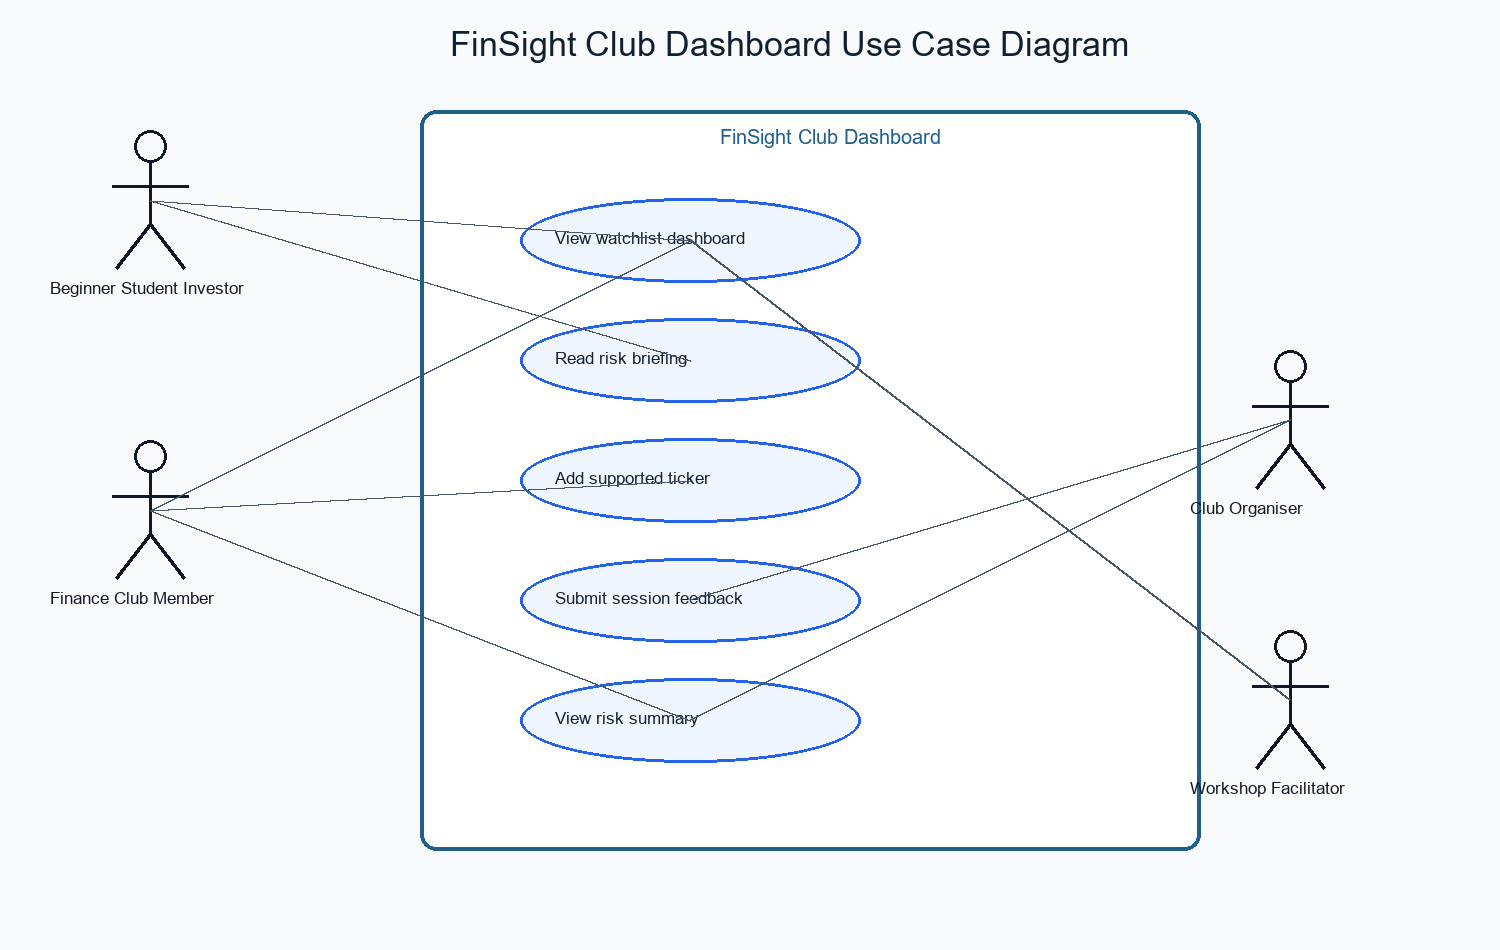

PlantUML online rendering unavailable; using local UML-style fallback.


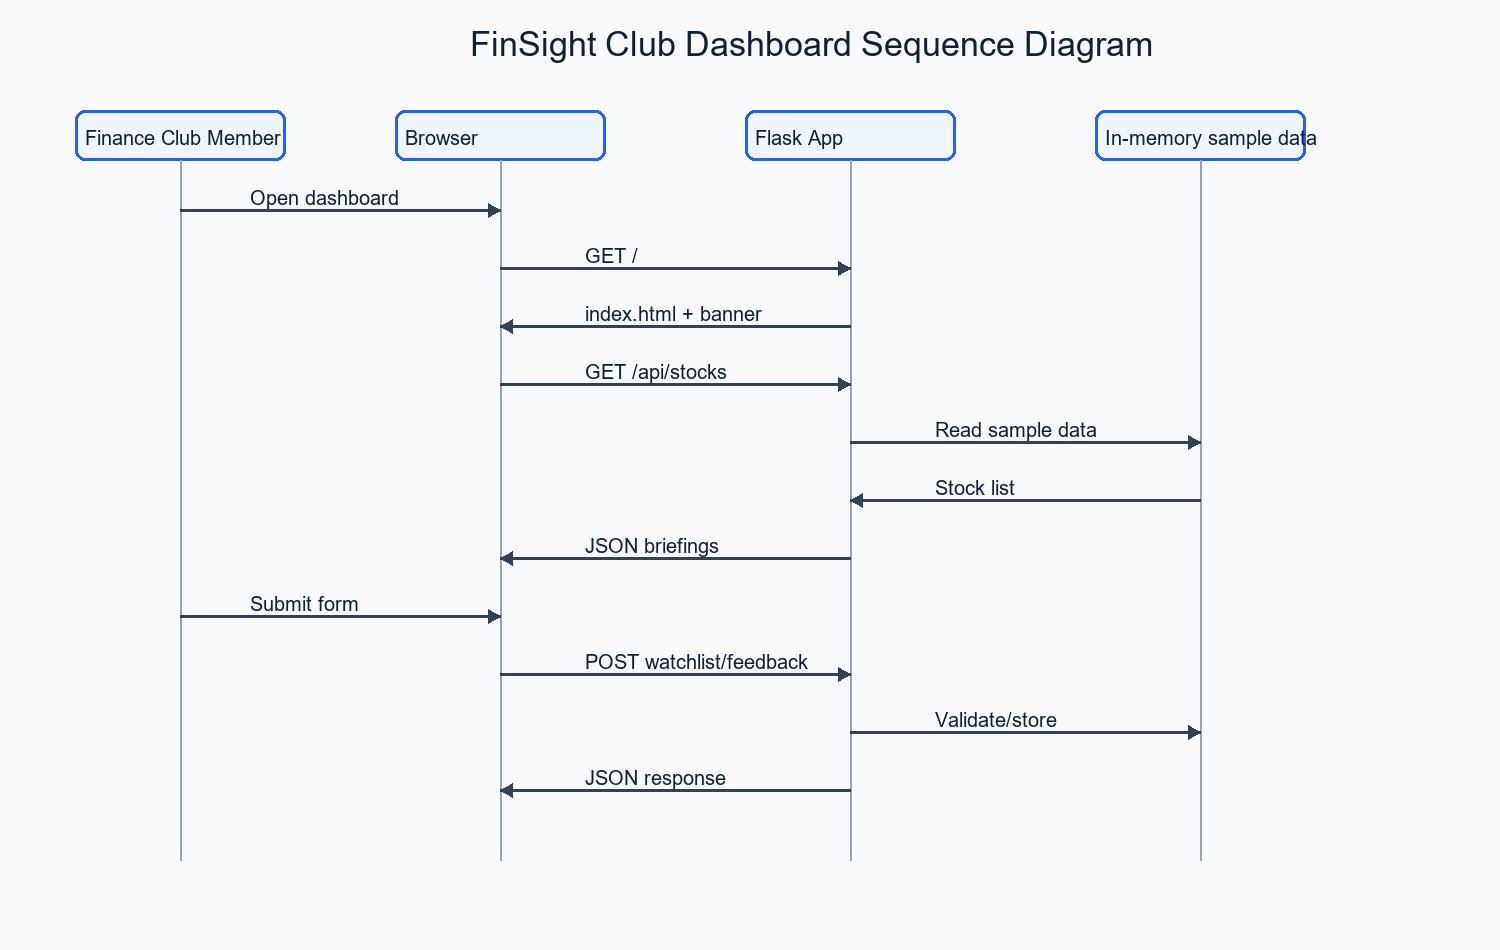

In [8]:
use_case_prompt = """Generate a PlantUML use case diagram for FinSight Club Dashboard.

User stories:
{user_stories_text}

Rules:
- Use actors: Beginner Student Investor, Finance Club Member, Club Organiser, Finance Workshop Facilitator.
- Use a rectangle system boundary named FinSight Club Dashboard.
- Use usecase ovals for view watchlist dashboard, read risk briefing, add supported ticker, submit session feedback, and view risk summary.
- Use actor-to-usecase associations.
- Return only PlantUML code from @startuml to @enduml.
""".strip()
sequence_prompt = """Generate a PlantUML sequence diagram for the generated Flask app.

API specification:
{api_spec}

Rules:
- Include User, Browser, Flask App, and In-memory sample data participants.
- Show GET /, GET /api/stocks, POST /api/watchlist or POST /api/feedback, validation/storage, and browser update.
- Return only PlantUML code from @startuml to @enduml.
""".strip()
print("Generating: UML diagrams")
use_case_fallback = '@startuml\nleft to right direction\ntitle FinSight Club Dashboard Use Case Diagram\nactor "Beginner Student Investor" as Beginner\nactor "Finance Club Member" as Member\nactor "Club Organiser" as Organiser\nactor "Finance Workshop Facilitator" as Facilitator\nrectangle "FinSight Club Dashboard" {\n  usecase "View watchlist dashboard" as UC1\n  usecase "Read risk briefing" as UC2\n  usecase "Add supported ticker" as UC3\n  usecase "Submit session feedback" as UC4\n  usecase "View risk summary" as UC5\n}\nBeginner -- UC1\nBeginner -- UC2\nMember -- UC1\nMember -- UC2\nMember -- UC3\nMember -- UC5\nOrganiser -- UC4\nOrganiser -- UC5\nFacilitator -- UC1\n@enduml\n'
sequence_fallback = '@startuml\nactor "Finance Club Member" as User\nparticipant Browser\nparticipant "Flask App" as Flask\nparticipant "In-memory sample data" as Data\nUser -> Browser: Open dashboard\nBrowser -> Flask: GET /\nFlask --> Browser: index.html with generated banner\nBrowser -> Flask: GET /api/stocks\nFlask -> Data: Read fixed sample stocks\nData --> Flask: Stock list\nFlask --> Browser: JSON stock briefings\nUser -> Browser: Add ticker or submit feedback\nBrowser -> Flask: POST /api/watchlist or POST /api/feedback\nFlask -> Data: Validate and store in memory\nFlask --> Browser: JSON response\nBrowser --> User: Update dashboard status\n@enduml\n'
if client:
    use_case_puml = clean_generated(get_completion(use_case_prompt, client, model_name, api_provider, temperature=0.2), language="text") or use_case_fallback
    sequence_puml = clean_generated(get_completion(sequence_prompt, client, model_name, api_provider, temperature=0.2), language="text") or sequence_fallback
else:
    use_case_puml = use_case_fallback
    sequence_puml = sequence_fallback
if "@startuml" not in use_case_puml or "@enduml" not in use_case_puml:
    use_case_puml = use_case_fallback
if "FinSight Club Dashboard" not in use_case_puml or "View risk summary" not in use_case_puml or "View session guidance" in use_case_puml:
    use_case_puml = use_case_fallback
if "@startuml" not in sequence_puml or "@enduml" not in sequence_puml:
    sequence_puml = sequence_fallback
save_text(DIAGRAM_DIR / "use_case_diagram.puml", use_case_puml)
save_text(DIAGRAM_DIR / "sequence_diagram.puml", sequence_puml)
preview_markdown("```plantuml\n" + use_case_puml + "\n```")

def draw_use_case_fallback(path):
    img = Image.new("RGB", (1500, 950), "#f8fafc")
    d = ImageDraw.Draw(img)
    try:
        title_font = ImageFont.truetype("arial.ttf", 34)
        font = ImageFont.truetype("arial.ttf", 20)
        small = ImageFont.truetype("arial.ttf", 17)
    except OSError:
        title_font = font = small = ImageFont.load_default()
    d.text((450, 25), "FinSight Club Dashboard Use Case Diagram", fill="#102033", font=title_font)
    d.rounded_rectangle((420, 110, 1200, 850), radius=16, outline="#1f5f8b", width=4, fill="#ffffff")
    d.text((720, 125), "FinSight Club Dashboard", fill="#1f5f8b", font=font)
    actors = {"Beginner Student Investor": (150, 190), "Finance Club Member": (150, 500), "Club Organiser": (1290, 410), "Workshop Facilitator": (1290, 690)}
    usecases = {"View watchlist dashboard": (690, 240), "Read risk briefing": (690, 360), "Add supported ticker": (690, 480), "Submit session feedback": (690, 600), "View risk summary": (690, 720)}
    def actor(x, y, label):
        d.ellipse((x-16, y-60, x+16, y-28), outline="#111827", width=3)
        d.line((x, y-28, x, y+34), fill="#111827", width=3)
        d.line((x-38, y-4, x+38, y-4), fill="#111827", width=3)
        d.line((x, y+34, x-34, y+78), fill="#111827", width=3)
        d.line((x, y+34, x+34, y+78), fill="#111827", width=3)
        d.text((x-100, y+88), label, fill="#111827", font=small)
    def oval(cx, cy, label):
        d.ellipse((cx-170, cy-42, cx+170, cy+42), outline="#2563eb", width=3, fill="#eff6ff")
        d.text((cx-135, cy-12), label, fill="#102033", font=small)
    for label, (x, y) in actors.items(): actor(x, y, label)
    for label, (x, y) in usecases.items(): oval(x, y, label)
    for a, u in [(actors["Beginner Student Investor"], usecases["View watchlist dashboard"]), (actors["Beginner Student Investor"], usecases["Read risk briefing"]), (actors["Finance Club Member"], usecases["View watchlist dashboard"]), (actors["Finance Club Member"], usecases["Add supported ticker"]), (actors["Finance Club Member"], usecases["View risk summary"]), (actors["Club Organiser"], usecases["Submit session feedback"]), (actors["Club Organiser"], usecases["View risk summary"]), (actors["Workshop Facilitator"], usecases["View watchlist dashboard"])]:
        d.line((a[0], a[1]+10, u[0], u[1]), fill="#475569", width=2)
    img.save(path)

def draw_sequence_fallback(path):
    img = Image.new("RGB", (1500, 950), "#f8fafc")
    d = ImageDraw.Draw(img)
    try:
        title_font = ImageFont.truetype("arial.ttf", 34)
        font = ImageFont.truetype("arial.ttf", 20)
    except OSError:
        title_font = font = ImageFont.load_default()
    d.text((470, 25), "FinSight Club Dashboard Sequence Diagram", fill="#102033", font=title_font)
    xs = [180, 500, 850, 1200]
    labels = ["Finance Club Member", "Browser", "Flask App", "In-memory sample data"]
    for x, label in zip(xs, labels):
        d.rounded_rectangle((x-105, 110, x+105, 160), radius=10, fill="#eff6ff", outline="#2563eb", width=3)
        d.text((x-95, 126), label, fill="#102033", font=font)
        d.line((x, 160, x, 860), fill="#94a3b8", width=2)
    steps = [(180,500,"Open dashboard"),(500,850,"GET /"),(850,500,"index.html + banner"),(500,850,"GET /api/stocks"),(850,1200,"Read sample data"),(1200,850,"Stock list"),(850,500,"JSON briefings"),(180,500,"Submit form"),(500,850,"POST watchlist/feedback"),(850,1200,"Validate/store"),(850,500,"JSON response")]
    y = 210
    for x1, x2, label in steps:
        d.line((x1, y, x2, y), fill="#334155", width=3)
        d.polygon([(x2, y), (x2-12 if x2>x1 else x2+12, y-7), (x2-12 if x2>x1 else x2+12, y+7)], fill="#334155")
        d.text(((x1+x2)//2-90, y-24), label, fill="#102033", font=font)
        y += 58
    img.save(path)

for puml, png_name, draw_fallback in [(use_case_puml, "use_case_diagram.png", draw_use_case_fallback), (sequence_puml, "sequence_diagram.png", draw_sequence_fallback)]:
    png_path = DIAGRAM_DIR / png_name
    if png_path.exists():
        png_path.unlink()
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            render_plantuml_diagram(puml, str(png_path.relative_to(TASK1_DIR)))
        if not png_path.exists():
            raise RuntimeError("PlantUML render produced no PNG")
    except Exception as exc:
        print("PlantUML online rendering unavailable; using local UML-style fallback.")
        draw_fallback(png_path)
    display(IPyImage(filename=str(png_path)))


#### 8) AI generated - Flask API

Generate Flask `main.py` from the generated PRD, API spec, and user stories.

In [9]:
print("Generating: Flask API")
main_py_prompt = 'You are a Python Flask engineer. Generate a complete Flask app in one file for the generated product FinSight Club Dashboard.\n\nPRD:\n{prd}\n\nAPI spec:\n{api_spec}\n\nRules:\n- Use fixed sample stock data only.\n- Include routes: /, /health, /api/stocks, /api/stocks/<ticker>, /api/watchlist, /api/risk-summary, /api/feedback, and /stock/<ticker>.\n- Serve index.html and stock_detail.html from the same folder.\n- Use in-memory watchlist and feedback storage.\n- Include the disclaimer: For educational demonstration only. Not financial advice.\n- Do not implement prediction, trading advice, buy/sell recommendation, portfolio optimisation, or investment recommendation.\n- Return only Python code.'
main_py_fallback = 'from flask import Flask, jsonify, request, send_from_directory\n\napp = Flask(__name__, static_folder="static")\n\nDISCLAIMER = "For educational demonstration only. Not financial advice."\n\nSTOCKS = [\n    {"ticker": "AAPL", "name": "Apple Inc.", "sector": "Technology hardware", "mock_price": 184.35, "risk_level": "medium", "briefing": "Device cycles, services growth, supply chain resilience, and consumer demand can affect discussion risk."},\n    {"ticker": "MSFT", "name": "Microsoft Corporation", "sector": "Cloud and productivity software", "mock_price": 421.16, "risk_level": "low", "briefing": "Diversified software and cloud revenue may reduce volatility, while infrastructure spending remains important."},\n    {"ticker": "NVDA", "name": "NVIDIA Corporation", "sector": "Semiconductors", "mock_price": 912.44, "risk_level": "high", "briefing": "AI chip demand, valuation, export controls, and supply capacity create a wider range of discussion risks."},\n    {"ticker": "TSLA", "name": "Tesla, Inc.", "sector": "Electric vehicles", "mock_price": 177.53, "risk_level": "high", "briefing": "Margins, delivery growth, battery costs, regulation, and leadership attention can influence uncertainty."},\n]\n\nwatchlist = []\nfeedback_items = []\n\n\ndef find_stock(ticker):\n    normalized = str(ticker or "").strip().upper()\n    return next((stock for stock in STOCKS if stock["ticker"] == normalized), None)\n\n\n@app.get("/health")\ndef health():\n    return jsonify(status="ok", service="FinSight Club Dashboard", disclaimer=DISCLAIMER)\n\n\n@app.get("/api/stocks")\ndef list_stocks():\n    return jsonify(stocks=STOCKS, count=len(STOCKS), disclaimer=DISCLAIMER)\n\n\n@app.get("/api/stocks/<ticker>")\ndef stock_detail(ticker):\n    stock = find_stock(ticker)\n    if stock is None:\n        return jsonify(error="stock_not_found", disclaimer=DISCLAIMER), 404\n    return jsonify(stock=stock, disclaimer=DISCLAIMER)\n\n\n@app.post("/api/watchlist")\ndef add_watchlist_item():\n    payload = request.get_json(silent=True) or {}\n    ticker = str(payload.get("ticker", "")).strip().upper()\n    if not ticker:\n        return jsonify(error="ticker is required", disclaimer=DISCLAIMER), 400\n    stock = find_stock(ticker)\n    if stock is None:\n        return jsonify(error="ticker is not in the educational sample dataset", disclaimer=DISCLAIMER), 404\n    if ticker not in watchlist:\n        watchlist.append(ticker)\n    return jsonify(message="ticker added", watchlist=watchlist, stock=stock, disclaimer=DISCLAIMER), 201\n\n\n@app.get("/api/watchlist")\ndef get_watchlist():\n    items = [stock for stock in STOCKS if stock["ticker"] in watchlist]\n    return jsonify(watchlist=items, tickers=watchlist, disclaimer=DISCLAIMER)\n\n\n@app.get("/api/risk-summary")\ndef risk_summary():\n    counts = {"low": 0, "medium": 0, "high": 0}\n    for stock in STOCKS:\n        counts[stock["risk_level"]] += 1\n    return jsonify(risk_summary=counts, disclaimer=DISCLAIMER)\n\n\n@app.post("/api/feedback")\ndef submit_feedback():\n    payload = request.get_json(silent=True) or {}\n    name = str(payload.get("name", "")).strip()\n    message = str(payload.get("message", "")).strip()\n    rating = payload.get("rating")\n    if not name or not message or rating is None:\n        return jsonify(error="name, message, and rating are required"), 400\n    try:\n        rating = int(rating)\n    except (TypeError, ValueError):\n        return jsonify(error="rating must be an integer"), 400\n    if rating < 1 or rating > 5:\n        return jsonify(error="rating must be between 1 and 5"), 400\n    item = {"id": len(feedback_items) + 1, "name": name, "message": message, "rating": rating}\n    feedback_items.append(item)\n    return jsonify(message="feedback submitted", feedback=item), 201\n\n\n@app.get("/api/feedback")\ndef list_feedback():\n    return jsonify(items=feedback_items, count=len(feedback_items))\n\n\n@app.get("/")\ndef index():\n    return send_from_directory(".", "index.html")\n\n\n@app.get("/stock/<ticker>")\ndef stock_detail_page(ticker):\n    return send_from_directory(".", "stock_detail.html")\n\n\n@app.get("/<path:filename>")\ndef serve_static_file(filename):\n    return send_from_directory(".", filename)\n\n\nif __name__ == "__main__":\n    app.run(host="0.0.0.0", port=5005, debug=False)\n'
if client:
    generated = get_completion(main_py_prompt, client, model_name, api_provider, temperature=0.3)
    main_py = clean_generated(generated, language='python') or main_py_fallback
else:
    main_py = main_py_fallback
if "Flask" not in main_py or "/api/stocks" not in main_py or "stock_detail.html" not in main_py:
    main_py = main_py_fallback
save_text(FLASK_DIR / "main.py", main_py)
route_lines = [line.strip() for line in main_py.splitlines() if line.strip().startswith("@app.")]
display(Markdown("**Flask route summary**\n\n" + "\n".join(f"- `{line}`" for line in route_lines)))


Generating: Flask API
Saved: Task1\artifacts\app\flask\main.py


**Flask route summary**

- `@app.get("/health")`
- `@app.get("/api/stocks")`
- `@app.get("/api/stocks/<ticker>")`
- `@app.post("/api/watchlist")`
- `@app.get("/api/watchlist")`
- `@app.get("/api/risk-summary")`
- `@app.post("/api/feedback")`
- `@app.get("/api/feedback")`
- `@app.get("/")`
- `@app.get("/stock/<ticker>")`
- `@app.get("/<path:filename>")`

#### 9) AI generated - Website

Generate `index.html` from the product context and reference the generated image path.

In [10]:
print("Generating: website")
index_html_prompt = 'You are a frontend engineer. Generate a single-file HTML website for the FinSight Club Dashboard Flask app.\n\nPRD:\n{prd}\n\nAPI spec:\n{api_spec}\n\nRules:\n- Display stock briefing cards from /api/stocks.\n- Display risk summary from /api/risk-summary.\n- Include add-to-watchlist and feedback forms.\n- Include a visible details link from each stock card to /stock/<ticker>.\n- Reference the image at static/generated_market_banner.png.\n- Include the exact visible disclaimer: For educational demonstration only. Not financial advice.\n- Keep it self-contained with CSS and JavaScript.\n- Do not include prediction, trading advice, buy/sell recommendation, or investment recommendation.\n- Return only HTML.'
index_html_fallback = '<!DOCTYPE html>\n<html lang="en">\n<head>\n  <meta charset="UTF-8" />\n  <meta name="viewport" content="width=device-width, initial-scale=1" />\n  <title>FinSight Club Dashboard</title>\n  <style>\n    :root { --bg: #f3f6fa; --panel: #ffffff; --ink: #172033; --muted: #667085; --line: #d8e0ea; --green: #166534; --amber: #b45309; --red: #b91c1c; }\n    * { box-sizing: border-box; }\n    body { margin: 0; font-family: Inter, Segoe UI, Arial, sans-serif; background: var(--bg); color: var(--ink); line-height: 1.55; }\n    .hero { background: #14324a; color: #fff; padding: 28px 0 24px; }\n    .wrap { width: min(1180px, calc(100% - 32px)); margin: 0 auto; }\n    .hero-grid { display: grid; grid-template-columns: 1.05fr .95fr; gap: 28px; align-items: center; }\n    .eyebrow { color: #9ee7c4; font-weight: 800; text-transform: uppercase; font-size: .82rem; }\n    h1 { margin: 8px 0 10px; font-size: clamp(2.3rem, 5vw, 4.2rem); line-height: 1.02; }\n    h2 { margin: 0 0 14px; font-size: 1.18rem; }\n    h3 { margin: 0; font-size: 1rem; }\n    .subtitle { max-width: 680px; color: #d8eaf6; margin: 0; font-size: 1.04rem; }\n    .metrics { display: grid; grid-template-columns: repeat(3, 1fr); gap: 10px; margin-top: 22px; }\n    .metric { border: 1px solid rgba(255,255,255,.24); border-radius: 8px; padding: 13px; background: rgba(255,255,255,.08); }\n    .metric strong { display: block; font-size: 1.45rem; }\n    .banner-frame { border-radius: 8px; overflow: hidden; border: 1px solid rgba(255,255,255,.28); box-shadow: 0 24px 60px rgba(0,0,0,.24); background: #0b1626; }\n    .banner { width: 100%; display: block; aspect-ratio: 16 / 7; object-fit: cover; }\n    .notice { margin-top: 18px; padding: 12px 14px; border: 1px solid rgba(251,191,36,.55); background: rgba(255,247,237,.12); border-radius: 8px; }\n    main { padding: 26px 0 42px; }\n    .layout { display: grid; grid-template-columns: minmax(0, 1.75fr) minmax(330px, .9fr); gap: 18px; align-items: start; }\n    .panel { background: var(--panel); border: 1px solid var(--line); border-radius: 8px; padding: 18px; box-shadow: 0 10px 28px rgba(15, 35, 63, .06); }\n    .cards { display: grid; grid-template-columns: repeat(auto-fit, minmax(235px, 1fr)); gap: 14px; }\n    .stock { border: 1px solid var(--line); border-radius: 8px; padding: 15px; background: #fff; }\n    .stock-top { display: flex; justify-content: space-between; gap: 10px; align-items: start; }\n    .ticker { font-size: 1.45rem; font-weight: 800; }\n    .muted { color: var(--muted); }\n    .price { font-weight: 800; margin-top: 8px; font-size: 1.1rem; }\n    .details-link { color: #1f6f50; font-weight: 800; }\n    .badge { display: inline-block; border-radius: 999px; padding: 4px 10px; font-size: .74rem; font-weight: 800; text-transform: uppercase; white-space: nowrap; }\n    .low { background: #dcfce7; color: var(--green); }\n    .medium { background: #fef3c7; color: var(--amber); }\n    .high { background: #fee2e2; color: var(--red); }\n    .side-stack { display: grid; gap: 18px; }\n    .summary { display: grid; grid-template-columns: repeat(3, 1fr); gap: 9px; margin-bottom: 14px; }\n    .summary div { border: 1px solid var(--line); border-radius: 8px; padding: 12px 8px; text-align: center; background: #f8fafc; }\n    .summary strong { display: block; font-size: 1.65rem; }\n    form { display: grid; gap: 10px; }\n    label { font-weight: 750; font-size: .88rem; }\n    input, textarea, button { width: 100%; border-radius: 8px; border: 1px solid var(--line); padding: 10px 12px; font: inherit; }\n    button { border: 0; background: #1f6f50; color: white; font-weight: 800; cursor: pointer; }\n    button.secondary { background: #334155; }\n    .status { min-height: 24px; color: var(--muted); font-size: .92rem; }\n    @media (max-width: 900px) { .hero-grid, .layout, .metrics { grid-template-columns: 1fr; } }\n  </style>\n</head>\n<body>\n  <section class="hero"><div class="wrap hero-grid"><div><div class="eyebrow">Educational stock risk dashboard</div><h1>FinSight Club Dashboard</h1><p class="subtitle">A Flask API and interactive dashboard for sample stock watchlists, plain-language risk briefings, and feedback collection.</p><div class="metrics"><div class="metric"><strong id="stockCount">0</strong><span>sample stocks</span></div><div class="metric"><strong>3</strong><span>risk levels</span></div><div class="metric"><strong>1</strong><span>feedback form</span></div></div><div class="notice">For educational demonstration only. Not financial advice. Prices are fixed mock values.</div></div><div class="banner-frame"><img class="banner" src="static/generated_market_banner.png" alt="Generated FinSight Club Dashboard market education banner" /></div></div></section>\n  <main class="wrap"><div class="layout"><section class="panel"><h2>Sample Stock Educational Briefings</h2><div id="stockCards" class="cards"></div></section><aside class="side-stack"><section class="panel"><h2>Risk Summary</h2><div class="summary"><div><strong id="lowCount">0</strong><span class="muted">Low</span></div><div><strong id="mediumCount">0</strong><span class="muted">Medium</span></div><div><strong id="highCount">0</strong><span class="muted">High</span></div></div></section><section class="panel"><h2>Add Watchlist Ticker</h2><form id="watchlistForm"><label for="ticker">Ticker</label><input id="ticker" name="ticker" placeholder="AAPL" maxlength="8" required /><button type="submit">Add ticker</button><div id="watchlistStatus" class="status"></div></form></section><section class="panel"><h2>Feedback</h2><form id="feedbackForm"><label for="name">Name</label><input id="name" name="name" required /><label for="rating">Rating 1-5</label><input id="rating" name="rating" type="number" min="1" max="5" required /><label for="message">Message</label><textarea id="message" name="message" rows="3" required></textarea><button class="secondary" type="submit">Submit feedback</button><div id="feedbackStatus" class="status"></div></form></section></aside></div></main>\n  <script>\n    const stockCards = document.getElementById("stockCards"); const watchlistStatus = document.getElementById("watchlistStatus"); const feedbackStatus = document.getElementById("feedbackStatus");\n    function escapeHtml(value) { return String(value ?? "").replace(/&/g,"&amp;").replace(/</g,"&lt;").replace(/>/g,"&gt;").replace(/"/g,"&quot;").replace(/\'/g,"&#039;"); }\n    async function loadStocks() { const [stocksResponse, riskResponse] = await Promise.all([fetch("/api/stocks"), fetch("/api/risk-summary")]); const stocksData = await stocksResponse.json(); const riskData = await riskResponse.json(); document.getElementById("stockCount").textContent = stocksData.count; stockCards.innerHTML = stocksData.stocks.map((stock) => `<article class="stock"><div class="stock-top"><div><div class="ticker">${escapeHtml(stock.ticker)}</div><h3>${escapeHtml(stock.name)}</h3></div><span class="badge ${escapeHtml(stock.risk_level)}">${escapeHtml(stock.risk_level)}</span></div><div class="muted">${escapeHtml(stock.sector)}</div><div class="price">$${Number(stock.mock_price).toFixed(2)}</div><p>${escapeHtml(stock.briefing)}</p><a class="details-link" href="/stock/${encodeURIComponent(stock.ticker)}">View details</a></article>`).join(""); document.getElementById("lowCount").textContent = riskData.risk_summary.low; document.getElementById("mediumCount").textContent = riskData.risk_summary.medium; document.getElementById("highCount").textContent = riskData.risk_summary.high; }\n    document.getElementById("watchlistForm").addEventListener("submit", async (event) => { event.preventDefault(); const ticker = document.getElementById("ticker").value.trim(); const response = await fetch("/api/watchlist", { method: "POST", headers: { "Content-Type": "application/json" }, body: JSON.stringify({ ticker }) }); const data = await response.json(); watchlistStatus.textContent = response.ok ? `Watchlist: ${data.watchlist.join(", ")}` : data.error; });\n    document.getElementById("feedbackForm").addEventListener("submit", async (event) => { event.preventDefault(); const payload = { name: document.getElementById("name").value.trim(), rating: document.getElementById("rating").value, message: document.getElementById("message").value.trim() }; const response = await fetch("/api/feedback", { method: "POST", headers: { "Content-Type": "application/json" }, body: JSON.stringify(payload) }); const data = await response.json(); feedbackStatus.textContent = response.ok ? "Feedback submitted." : data.error; if (response.ok) event.target.reset(); });\n    loadStocks().catch(() => { stockCards.innerHTML = "<p>Unable to load stock data. Start the Flask API and refresh.</p>"; });\n  </script>\n</body>\n</html>\n'
if client:
    generated = get_completion(index_html_prompt, client, model_name, api_provider, temperature=0.3)
    index_html = clean_generated(generated, language='html') or index_html_fallback
else:
    index_html = index_html_fallback
if "generated_market_banner.png" not in index_html or "For educational demonstration only. Not financial advice." not in index_html or "View details" not in index_html:
    index_html = index_html_fallback
index_html = index_html.replace("A Flask API and interactive dashboard", "An interactive dashboard")
footer_text = "Fixed sample data | Session discussion support | No financial advice"
if footer_text not in index_html:
    index_html = index_html.replace("  <script>", f"  <footer class=\"wrap muted\">{footer_text}</footer>\n  <script>")
save_text(FLASK_DIR / "index.html", index_html)

stock_detail_html_prompt = 'Generate a self-contained English HTML stock detail page for FinSight Club Dashboard. Read the ticker from /stock/<ticker>, fetch /api/stocks/<ticker>, show ticker, company, sector, mock price, risk level, educational briefing, disclaimer, and a visible Back to dashboard link. Return only HTML.'
stock_detail_html_fallback = '<!DOCTYPE html>\n<html lang="en">\n<head>\n  <meta charset="UTF-8" />\n  <meta name="viewport" content="width=device-width, initial-scale=1" />\n  <title>Stock Detail | FinSight Club Dashboard</title>\n  <style>\n    :root { --bg: #f3f6fa; --panel: #ffffff; --ink: #172033; --muted: #667085; --line: #d8e0ea; --green: #166534; --amber: #b45309; --red: #b91c1c; }\n    * { box-sizing: border-box; }\n    body { margin: 0; font-family: Inter, Segoe UI, Arial, sans-serif; background: var(--bg); color: var(--ink); line-height: 1.55; }\n    .wrap { width: min(760px, calc(100% - 32px)); margin: 0 auto; }\n    header { background: #14324a; color: #fff; padding: 28px 0; }\n    main { padding: 26px 0 42px; }\n    .panel { background: var(--panel); border: 1px solid var(--line); border-radius: 8px; padding: 20px; box-shadow: 0 10px 28px rgba(15, 35, 63, .06); }\n    h1, h2 { margin: 0 0 10px; }\n    .muted { color: var(--muted); }\n    .price { font-size: 1.2rem; font-weight: 800; }\n    .badge { display: inline-block; border-radius: 999px; padding: 4px 10px; font-size: .74rem; font-weight: 800; text-transform: uppercase; }\n    .low { background: #dcfce7; color: var(--green); }\n    .medium { background: #fef3c7; color: var(--amber); }\n    .high { background: #fee2e2; color: var(--red); }\n    a { color: #1f6f50; font-weight: 800; }\n    .back { display: inline-block; margin-top: 18px; }\n  </style>\n</head>\n<body>\n  <header><div class="wrap"><h1>FinSight Club Dashboard</h1><div>Educational stock briefing detail</div></div></header>\n  <main class="wrap">\n    <section id="detail" class="panel"><p>Loading stock detail...</p></section>\n    <a class="back" href="/">Back to dashboard</a>\n  </main>\n  <script>\n    const detail = document.getElementById("detail");\n    const ticker = decodeURIComponent(window.location.pathname.split("/").filter(Boolean).pop() || "").toUpperCase();\n    function escapeHtml(value) { return String(value ?? "").replace(/&/g,"&amp;").replace(/</g,"&lt;").replace(/>/g,"&gt;").replace(/"/g,"&quot;").replace(/\'/g,"&#039;"); }\n    async function loadStockDetail() {\n      const response = await fetch(`/api/stocks/${encodeURIComponent(ticker)}`);\n      if (!response.ok) {\n        detail.innerHTML = "<h2>Stock not found</h2><p class=\\"muted\\">This ticker is not in the educational sample dataset.</p>";\n        return;\n      }\n      const data = await response.json();\n      const stock = data.stock;\n      detail.innerHTML = `<h2>${escapeHtml(stock.ticker)} - ${escapeHtml(stock.name)}</h2><p class="muted">${escapeHtml(stock.sector)}</p><p class="price">$${Number(stock.mock_price).toFixed(2)}</p><span class="badge ${escapeHtml(stock.risk_level)}">${escapeHtml(stock.risk_level)} risk</span><h3>Educational risk briefing</h3><p>${escapeHtml(stock.briefing)}</p><p class="muted">${escapeHtml(data.disclaimer)}</p>`;\n    }\n    loadStockDetail().catch(() => { detail.innerHTML = "<h2>Unable to load stock detail</h2><p class=\\"muted\\">Please return to the dashboard and try again.</p>"; });\n  </script>\n</body>\n</html>\n'
if client:
    generated = get_completion(stock_detail_html_prompt, client, model_name, api_provider, temperature=0.3)
    stock_detail_html = clean_generated(generated, language='html') or stock_detail_html_fallback
else:
    stock_detail_html = stock_detail_html_fallback
if "/api/stocks/" not in stock_detail_html or "Back to dashboard" not in stock_detail_html:
    stock_detail_html = stock_detail_html_fallback
save_text(FLASK_DIR / "stock_detail.html", stock_detail_html)
website_sections = [
    "Hero with generated market banner image",
    "Sample stock briefing cards loaded from /api/stocks",
    "Risk summary loaded from /api/risk-summary",
    "Add-to-watchlist form",
    "Post-session feedback form",
    "Visible educational disclaimer",
    "Stock detail navigation backed by /api/stocks/<ticker>",
]
display(Markdown("**Website section preview**\n\n" + "\n".join(f"- {section}" for section in website_sections)))


requirements_txt_prompt = 'Based on the generated Flask application code, generate requirements.txt with one dependency per line. Include Flask, pytest, Pillow, and python-dotenv if needed. Do not include standard library modules.'
requirements_txt_fallback = 'Flask>=3.0\npytest>=8.0\nPillow>=10.0\npython-dotenv>=1.0\n'
if client:
    generated = get_completion(requirements_txt_prompt, client, model_name, api_provider, temperature=0.3)
    requirements_txt = clean_generated(generated, language='text') or requirements_txt_fallback
else:
    requirements_txt = requirements_txt_fallback
requirements_lines = [line.strip() for line in requirements_txt.splitlines() if line.strip()]
required_dependencies = ("Flask", "pytest", "Pillow", "python-dotenv")
if not all(name in requirements_txt for name in required_dependencies) or any(" " in line or line.startswith("[") for line in requirements_lines):
    requirements_txt = requirements_txt_fallback
save_text(FLASK_DIR / "requirements.txt", requirements_txt)
display(Markdown("```\n" + requirements_txt[:2600] + "\n```"))


Generating: website
Saved: Task1\artifacts\app\flask\index.html
Saved: Task1\artifacts\app\flask\stock_detail.html


**Website section preview**

- Hero with generated market banner image
- Sample stock briefing cards loaded from /api/stocks
- Risk summary loaded from /api/risk-summary
- Add-to-watchlist form
- Post-session feedback form
- Visible educational disclaimer
- Stock detail navigation backed by /api/stocks/<ticker>

Saved: Task1\artifacts\app\flask\requirements.txt


```
Flask>=3.0
pytest>=8.0
Pillow>=10.0
python-dotenv>=1.0

```

#### 10) AI generated - Website Image

Use the course image utility when available; otherwise create a local educational banner fallback.

Generating: website image
{'image_status': 'python_generated_banner', 'path': 'Task1\\artifacts\\app\\flask\\static\\generated_market_banner.png', 'bytes': 56813}


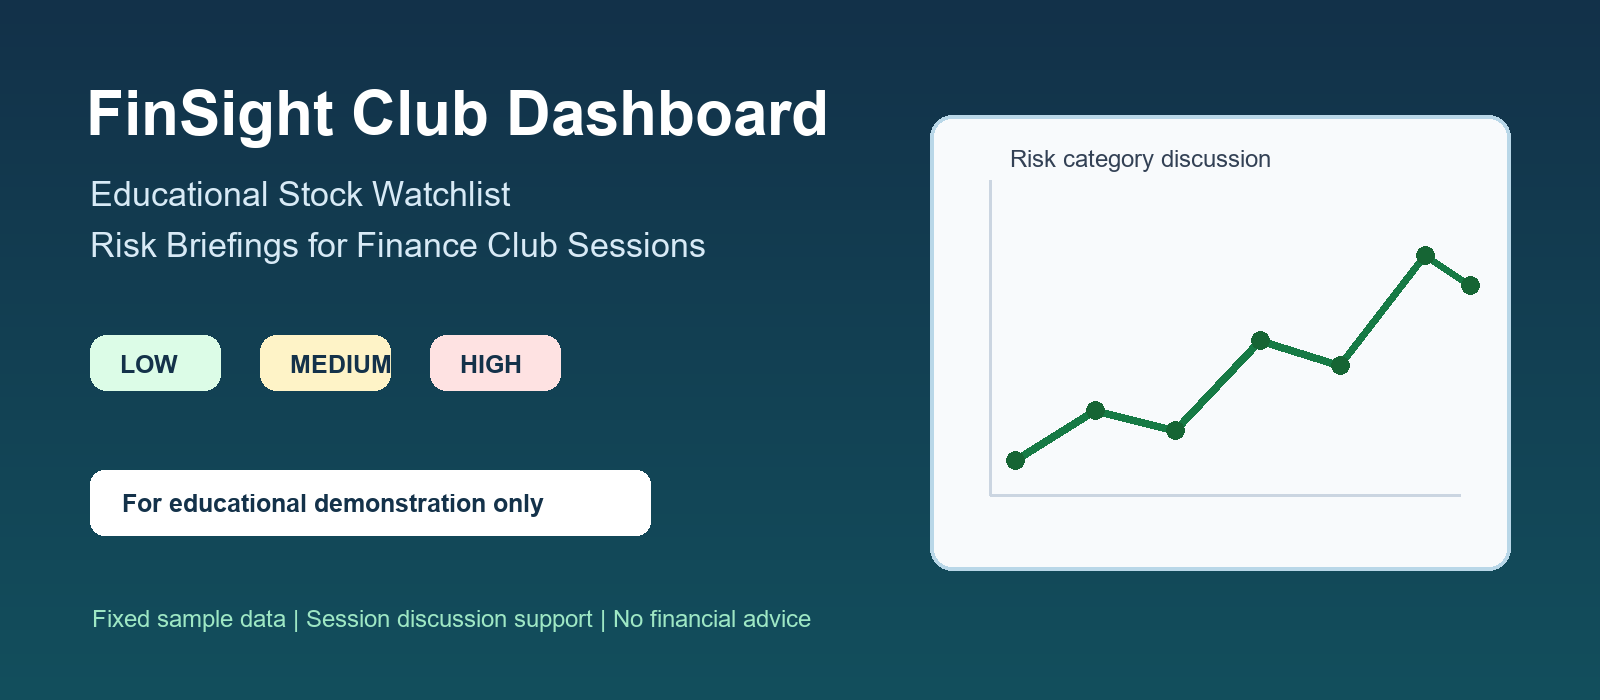

In [11]:
print("Generating: website image")
image_prompt = """
Create a clean educational market banner for a university finance club web app named FinSight Club Dashboard. Use product-facing English text, balanced spacing, abstract chart lines, and a professional classroom tone. No logos.
""".strip()
image_path = STATIC_DIR / "generated_market_banner.png"
image_status = "python_generated_banner"
try:
    # Deterministic Pillow layout keeps all website text readable and product-facing.
    if image_client and image_api_provider == "apifree":
        result = get_image_generation_completion(image_prompt, image_client, image_model_name, image_api_provider)
        candidate = result[0] if isinstance(result, tuple) and result else result if isinstance(result, str) else None
        if candidate and Path(candidate).exists():
            image_path.write_bytes(Path(candidate).read_bytes())
            image_status = "apifree_image_generation"
        else:
            raise RuntimeError("image API returned no local file")
    else:
        raise RuntimeError("APIFree image client unavailable")
except Exception:
    image_status = "python_generated_banner"
    img = Image.new("RGB", (1600, 700), "#123149")
    d = ImageDraw.Draw(img)
    for y in range(700):
        d.line((0, y, 1600, y), fill=(18, int(49 + 30 * y / 700), int(73 + 20 * y / 700)))
    try:
        title = ImageFont.truetype("arialbd.ttf", 62)
        sub = ImageFont.truetype("arial.ttf", 34)
        label = ImageFont.truetype("arialbd.ttf", 25)
        small = ImageFont.truetype("arial.ttf", 24)
    except OSError:
        title = sub = label = small = ImageFont.load_default()
    # Left-side text area is intentionally kept clear of the chart panel.
    d.text((86, 78), "FinSight Club Dashboard", fill="white", font=title)
    d.text((90, 175), "Educational Stock Watchlist", fill="#d8eaf6", font=sub)
    d.text((90, 226), "Risk Briefings for Finance Club Sessions", fill="#d8eaf6", font=sub)
    chips = [("LOW", "#dcfce7"), ("MEDIUM", "#fef3c7"), ("HIGH", "#fee2e2")]
    for i, (text, color) in enumerate(chips):
        x = 90 + i * 170
        d.rounded_rectangle((x, 335, x + 130, 390), radius=16, fill=color)
        d.text((x + 30, 350), text, fill="#14324a", font=label)
    d.rounded_rectangle((90, 470, 650, 535), radius=14, fill="#ffffff")
    d.text((122, 489), "For educational demonstration only", fill="#14324a", font=label)
    d.text((92, 605), "Fixed sample data | Session discussion support | No financial advice", fill="#9ee7c4", font=small)
    panel = (930, 115, 1510, 570)
    d.rounded_rectangle(panel, radius=22, fill="#f8fafc", outline="#b9d7e8", width=4)
    # Chart is placed fully inside the panel with generous padding.
    axis = (990, 495, 1460, 180)
    d.line((axis[0], axis[1], axis[2], axis[1]), fill="#cbd5e1", width=3)
    d.line((axis[0], axis[1], axis[0], axis[3]), fill="#cbd5e1", width=3)
    points = [(1015, 460), (1095, 410), (1175, 430), (1260, 340), (1340, 365), (1425, 255), (1470, 285)]
    d.line(points, fill="#167a45", width=8)
    for px, py in points:
        d.ellipse((px - 9, py - 9, px + 9, py + 9), fill="#166534")
    d.text((1010, 145), "Risk category discussion", fill="#334155", font=small)
    img.save(image_path)
print({"image_status": image_status, "path": str(image_path.relative_to(REPO_ROOT)), "bytes": image_path.stat().st_size})
display(IPyImage(filename=str(image_path)))

# Phase 3: Operation

The operation phase generates tests and run files for the product.

#### 11) AI generated - Tests

Generate pytest coverage for core endpoints and validation paths.

In [12]:
print("Generating: tests")
test_app_py_prompt = 'You are a Python test engineer. Generate pytest tests for the Flask app based on this API specification and code.\n\nAPI spec:\n{api_spec}\n\nFlask code:\n{main_py}\n\nRules:\n- Use Flask test_client.\n- Test /health, /api/stocks, /api/stocks/<ticker>, /api/watchlist, /api/risk-summary, /api/feedback, /, /stock/<ticker>, detail navigation, and generated image file existence.\n- Include validation/error-path tests.\n- Return only Python code.'
test_app_py_fallback = 'import sys\nfrom pathlib import Path\n\nAPP_DIR = Path(__file__).resolve().parents[1] / "flask"\nsys.path.insert(0, str(APP_DIR))\n\nfrom main import app, feedback_items, watchlist  # noqa: E402\n\n\ndef client():\n    app.config.update(TESTING=True)\n    watchlist.clear()\n    feedback_items.clear()\n    return app.test_client()\n\n\ndef test_health_endpoint():\n    response = client().get("/health")\n    assert response.status_code == 200\n    assert response.get_json()["status"] == "ok"\n\n\ndef test_stocks_have_required_fields():\n    response = client().get("/api/stocks")\n    data = response.get_json()\n    assert response.status_code == 200\n    assert data["count"] >= 3\n    for stock in data["stocks"]:\n        assert {"ticker", "name", "mock_price", "risk_level", "briefing"} <= stock.keys()\n\n\ndef test_stock_detail_and_unknown_ticker():\n    assert client().get("/api/stocks/AAPL").status_code == 200\n    assert client().get("/api/stocks/UNKNOWN").status_code == 404\n\n\ndef test_stock_detail_page_supports_client_side_api_fetch():\n    response = client().get("/stock/AAPL")\n    html = response.get_data(as_text=True)\n    assert response.status_code == 200\n    assert "/api/stocks/" in html\n    assert "Back to dashboard" in html\n    assert "Stock not found" in html\n\n\ndef test_index_page_has_stock_detail_navigation():\n    response = client().get("/")\n    html = response.get_data(as_text=True)\n    assert response.status_code == 200\n    assert "View details" in html\n    assert \'href="/stock/${encodeURIComponent(stock.ticker)}"\' in html\n\n\ndef test_watchlist_validation_and_success():\n    test_client = client()\n    assert test_client.post("/api/watchlist", json={}).status_code == 400\n    assert test_client.post("/api/watchlist", json={"ticker": "ZZZZ"}).status_code == 404\n    created = test_client.post("/api/watchlist", json={"ticker": "msft"})\n    assert created.status_code == 201\n    assert "MSFT" in created.get_json()["watchlist"]\n\n\ndef test_feedback_validation_and_success():\n    test_client = client()\n    assert test_client.post("/api/feedback", json={"name": "Feiyu"}).status_code == 400\n    assert test_client.post("/api/feedback", json={"name": "Feiyu", "message": "Clear", "rating": 6}).status_code == 400\n    valid = test_client.post("/api/feedback", json={"name": "Feiyu", "message": "Clear dashboard", "rating": 5})\n    assert valid.status_code == 201\n    assert valid.get_json()["feedback"]["rating"] == 5\n\n\ndef test_risk_summary_shape():\n    response = client().get("/api/risk-summary")\n    assert response.status_code == 200\n    assert set(response.get_json()["risk_summary"]) == {"low", "medium", "high"}\n\n\ndef test_index_page_and_generated_image_reference():\n    response = client().get("/")\n    html = response.get_data(as_text=True)\n    assert response.status_code == 200\n    assert "generated_market_banner.png" in html\n    assert "For educational demonstration only" in html\n\n\ndef test_generated_image_file_exists():\n    image_path = APP_DIR / "static" / "generated_market_banner.png"\n    assert image_path.exists()\n    assert image_path.stat().st_size > 0\n\n\ndef test_feedback_get_returns_submitted_items():\n    test_client = client()\n    assert test_client.post("/api/feedback", json={"name": "Feiyu", "message": "Useful risk summary", "rating": 4}).status_code == 201\n    response = test_client.get("/api/feedback")\n    assert response.status_code == 200\n    assert response.get_json()["count"] == 1\n'
if client:
    generated = get_completion(test_app_py_prompt, client, model_name, api_provider, temperature=0.3)
    test_app_py = clean_generated(generated, language='python') or test_app_py_fallback
else:
    test_app_py = test_app_py_fallback
test_app_py = test_app_py.replace('assert "For educational demonstration only" in html', 'assert "For educational demonstration only. Not financial advice." in html')
required_test_tokens = ('Path(__file__).resolve().parents[1] / "flask"', 'sys.path.insert', '/health', '/api/stocks', '/api/watchlist', '/api/feedback', '/api/risk-summary', 'generated_market_banner.png', 'For educational demonstration only. Not financial advice.')
if not all(token in test_app_py for token in required_test_tokens):
    test_app_py = test_app_py_fallback
save_text(TEST_DIR / "test_app.py", test_app_py)
import subprocess
pytest_result = subprocess.run([sys.executable, "-m", "pytest", str(TEST_DIR), "-q", "--color=no"], cwd=str(REPO_ROOT), text=True, capture_output=True)
pytest_output = (pytest_result.stdout + pytest_result.stderr).strip()
save_text(REPO_ROOT / "Task2" / "test_results" / "pytest_output.txt", pytest_output)
summary_line = pytest_output.splitlines()[-1] if pytest_output else "pytest produced no output"
display(Markdown(f"**Pytest summary:** `{summary_line}`"))


Generating: tests
Saved: Task1\artifacts\app\tests\test_app.py


Saved: Task2\test_results\pytest_output.txt


**Pytest summary:** `11 passed in 0.27s`

#### 12) AI generated - Docker Files

Generate compact container files for local execution.

In [13]:
print("Generating: Docker files")
dockerfile_prompt = 'Generate a Dockerfile for the generated Flask app. Use python:3.11-slim, copy flask/requirements.txt, install dependencies, copy flask files, expose 5005, and run python main.py. Return only Dockerfile content.'
dockerfile_fallback = 'FROM python:3.11-slim\n\nWORKDIR /app\n\nCOPY flask/requirements.txt .\nRUN pip install --no-cache-dir -r requirements.txt\n\nCOPY flask/ .\n\nEXPOSE 5005\nENV FLASK_APP=main.py\nENV FLASK_ENV=production\n\nCMD ["python", "main.py"]\n'
if client:
    generated = get_completion(dockerfile_prompt, client, model_name, api_provider, temperature=0.3)
    dockerfile = clean_generated(generated, language='dockerfile') or dockerfile_fallback
else:
    dockerfile = dockerfile_fallback

save_text(DOCKER_DIR / "Dockerfile", dockerfile)
display(Markdown("```\n" + dockerfile[:2600] + "\n```"))


docker_compose_prompt = 'Generate docker-compose.yml for the generated Flask app. Service name finsight-club-dashboard, build context .., dockerfile docker/Dockerfile, container name finsight-builder, map 5005:5005. Return only YAML.'
docker_compose_fallback = 'services:\n  finsight-builder:\n    build:\n      context: ..\n      dockerfile: docker/Dockerfile\n    container_name: finsight-club-dashboard\n    ports:\n      - "5005:5005"\n    environment:\n      - FLASK_ENV=production\n      - FLASK_APP=main.py\n    restart: unless-stopped\n'
if client:
    generated = get_completion(docker_compose_prompt, client, model_name, api_provider, temperature=0.3)
    docker_compose = clean_generated(generated, language='yaml') or docker_compose_fallback
else:
    docker_compose = docker_compose_fallback

save_text(DOCKER_DIR / "docker-compose.yml", docker_compose)
display(Markdown("```\n" + docker_compose[:2600] + "\n```"))



Generating: Docker files
Saved: Task1\artifacts\app\docker\Dockerfile


```
FROM python:3.11-slim

WORKDIR /app

COPY flask/requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY flask/ .

EXPOSE 5005
ENV FLASK_APP=main.py
ENV FLASK_ENV=production

CMD ["python", "main.py"]

```

Saved: Task1\artifacts\app\docker\docker-compose.yml


```
services:
  finsight-builder:
    build:
      context: ..
      dockerfile: docker/Dockerfile
    container_name: finsight-club-dashboard
    ports:
      - "5005:5005"
    environment:
      - FLASK_ENV=production
      - FLASK_APP=main.py
    restart: unless-stopped

```

#### 13) AI generated - CI Workflow

Generate a workflow file for real automation without claiming it has run.

In [14]:
print("Generating: CI workflow")
ci_yml_prompt = 'Generate a GitHub Actions workflow for the generated FinSight Club Dashboard app.\n\nRules:\n- Trigger on push and pull_request.\n- Use Python 3.11.\n- Install dependencies from Task1/artifacts/app/flask/requirements.txt.\n- Run python -m pytest Task1/artifacts/app/tests -q.\n- Build Docker image with Task1/artifacts/app/docker/Dockerfile and context Task1/artifacts/app.\n- Return only YAML.'
ci_yml_fallback = 'name: FinSight Club Dashboard CI\n\non:\n  push:\n  pull_request:\n\njobs:\n  test-and-build:\n    runs-on: ubuntu-latest\n    steps:\n      - name: Check out repository\n        uses: actions/checkout@v6\n\n      - name: Set up Python\n        uses: actions/setup-python@v6\n        with:\n          python-version: "3.11"\n\n      - name: Install dependencies\n        run: |\n          python -m pip install --upgrade pip\n          pip install -r Task1/artifacts/app/flask/requirements.txt\n\n      - name: Run pytest\n        run: python -m pytest Task1/artifacts/app/tests -q\n\n      - name: Build Docker image\n        run: docker build -f Task1/artifacts/app/docker/Dockerfile Task1/artifacts/app\n'
if client:
    generated = get_completion(ci_yml_prompt, client, model_name, api_provider, temperature=0.3)
    ci_yml = clean_generated(generated, language='yaml') or ci_yml_fallback
else:
    ci_yml = ci_yml_fallback
if "pytest" not in ci_yml or "docker build" not in ci_yml:
    ci_yml = ci_yml_fallback
save_text(CI_DIR / "ci.yml", ci_yml)
display(Markdown("```\n" + ci_yml[:2600] + "\n```"))

save_text(TASK2_WORKFLOW_DIR / "ci.yml", ci_yml)
save_text(ROOT_CI_DIR / "ci.yml", ci_yml)


Generating: CI workflow
Saved: Task1\artifacts\app\.github\workflows\ci.yml


```
name: FinSight Club Dashboard CI

on:
  push:
  pull_request:

jobs:
  test-and-build:
    runs-on: ubuntu-latest
    steps:
      - name: Check out repository
        uses: actions/checkout@v6

      - name: Set up Python
        uses: actions/setup-python@v6
        with:
          python-version: "3.11"

      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r Task1/artifacts/app/flask/requirements.txt

      - name: Run pytest
        run: python -m pytest Task1/artifacts/app/tests -q

      - name: Build Docker image
        run: docker build -f Task1/artifacts/app/docker/Dockerfile Task1/artifacts/app

```

Saved: Task2\github_workflow_copy\ci.yml
Saved: .github\workflows\ci.yml


#### 14) Generated Artefacts Summary

Record the generated file list and practical run commands.

In [15]:
references_text = "# Software Source Transparency\n\nThe FinSight Builder notebook extends the teacher-provided DTS114TC baseline practical. The generated application uses the following references:\n\n1. DTS114TC teaching team. (2026). *From Co-pilot to Creator: Following the AI-Driven Development Lifecycle Methodology* [Jupyter notebook].\n2. Xi'an Jiaotong-Liverpool University. (2026). *DTS114TC CW-Software-Component* [Coursework brief].\n3. Pallets Projects. (n.d.). *Flask documentation*. https://flask.palletsprojects.com/\n4. pytest developers. (n.d.). *pytest documentation*. https://docs.pytest.org/\n5. Docker, Inc. (n.d.). *Dockerfile reference*. https://docs.docker.com/reference/dockerfile/\n6. Docker, Inc. (n.d.). *Docker Compose documentation*. https://docs.docker.com/compose/\n7. GitHub, Inc. (n.d.). *GitHub Actions documentation*. https://docs.github.com/actions\n8. PlantUML. (n.d.). *PlantUML language reference guide*. https://plantuml.com/guide\n\nAccessed 1 June 2026.\n"
save_text(ARTIFACTS / "references.md", references_text)

generated_files = [
    ARTIFACTS / "problem_statement.md",
    ARTIFACTS / "personas.md",
    ARTIFACTS / "prd.md",
    ARTIFACTS / "user_stories.json",
    ARTIFACTS / "api_spec.md",
    ARTIFACTS / "references.md",
    DIAGRAM_DIR / "use_case_diagram.puml",
    DIAGRAM_DIR / "use_case_diagram.png",
    DIAGRAM_DIR / "sequence_diagram.puml",
    DIAGRAM_DIR / "sequence_diagram.png",
    FLASK_DIR / "main.py",
    FLASK_DIR / "index.html",
    FLASK_DIR / "stock_detail.html",
    FLASK_DIR / "requirements.txt",
    STATIC_DIR / "generated_market_banner.png",
    TEST_DIR / "test_app.py",
    DOCKER_DIR / "Dockerfile",
    DOCKER_DIR / "docker-compose.yml",
    CI_DIR / "ci.yml",
]
missing = [str(path.relative_to(REPO_ROOT)) for path in generated_files if not path.exists()]
manifest = {
    "project": "FinSight Builder",
    "generated_application": "FinSight Club Dashboard",
    "business_problem": business_problem,
    "generated_files": [str(path.relative_to(TASK1_DIR)) for path in generated_files],
    "missing": missing,
    "boundary": "Educational sample data only; no prediction, trading advice, or investment recommendation functionality.",
}
save_text(ARTIFACTS / "generation_manifest.json", json.dumps(manifest, indent=2))
display(Markdown("**Generated artefacts:** " + str(len(generated_files) - len(missing)) + "/" + str(len(generated_files)) + " files present."))
print("Run tests: python -m pytest Task1/artifacts/app/tests -q")
print("Run Flask: python Task1/artifacts/app/flask/main.py")
print("Run Docker: docker compose -f Task1/artifacts/app/docker/docker-compose.yml up --build")


Saved: Task1\artifacts\references.md
Saved: Task1\artifacts\generation_manifest.json


**Generated artefacts:** 19/19 files present.

Run tests: python -m pytest Task1/artifacts/app/tests -q
Run Flask: python Task1/artifacts/app/flask/main.py
Run Docker: docker compose -f Task1/artifacts/app/docker/docker-compose.yml up --build
